## Exploratory Data Analysis and Visualization

### Initial Data Exploration

Import the necessary libraries.

In [75]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

Load the cleaned employee profiles dataset.

In [76]:
df = pd.read_csv("../data/employee_profiles_cleaned.csv")

Examine the dataset structure.

In [77]:
display(df.head())
df.info()

,employee_id,age,salary,promotion_eligible,last_training_date,department,work_experience,projects_completed,hours_worked_weekly,work_mode,last_promotion_date,satisfaction_score,overtime_hours,graduation_year,educational_background
0,E0001,54.0,104328.0,Y,2023-08-15,Hr,16,14.0,43.3,remote,2022-05-10,6.0,8.40,2011,Psychology
1,E0002,41.0,64761.0,N,2023-08-15,Finance,1,8.0,53.3,hybrid,2022-05-10,6.0,8.10,1995,Architecture
2,E0003,54.0,104328.0,N,2023-08-15,Marketing,8,6.0,32.6,hybrid,2022-10-05,10.0,5.20,2007,Business Administration
3,E0004,41.0,104328.0,No,2023-08-15,Finance,16,1.0,37.8,remote,2022-05-10,5.0,6.15,2000,Business Administration
4,E0005,29.0,61486.0,Y,2023-08-15,Finance,16,1.0,53.3,hybrid,2022-05-10,6.0,0.30,1991,Medicine


<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   employee_id             100 non-null    str    
 1   age                     100 non-null    float64
 2   salary                  100 non-null    float64
 3   promotion_eligible      100 non-null    str    
 4   last_training_date      100 non-null    str    
 5   department              100 non-null    str    
 6   work_experience         100 non-null    int64  
 7   projects_completed      100 non-null    float64
 8   hours_worked_weekly     100 non-null    float64
 9   work_mode               100 non-null    str    
 10  last_promotion_date     100 non-null    str    
 11  satisfaction_score      100 non-null    float64
 12  overtime_hours          100 non-null    float64
 13  graduation_year         100 non-null    int64  
 14  educational_background  100 non-null    str    
dtypes

### Descriptive Statistics

Generate summary statistics for some of the numerical columns.

In [78]:
numerical_stats = df[[ 'salary', 'hours_worked_weekly', 'satisfaction_score', 'projects_completed', 'overtime_hours' ]].describe()
display(numerical_stats)

,salary,hours_worked_weekly,satisfaction_score,projects_completed,overtime_hours
count,100.000000,100.000000,100.000000,100.000000,100.00000
mean,89979.820000,43.355000,5.740000,7.550000,5.77800
std,19454.999621,6.957205,2.281325,3.430037,2.38636
min,51438.000000,30.100000,1.000000,0.000000,0.00000
25%,73905.750000,39.725000,5.000000,8.000000,4.90000
50%,100333.000000,43.300000,6.000000,8.000000,6.15000
75%,104328.000000,46.475000,6.000000,8.000000,7.20000
max,118824.000000,59.400000,10.000000,15.000000,9.80000


### Pattern Identification

Calculate average satisfaction scores by department.

In [79]:
satisfaction_scores_by_department = df.groupby(['department'])['satisfaction_score'].agg('mean').round(2)
print(satisfaction_scores_by_department)

department
Engineering    6.48
Finance        5.61
Hr             5.12
Marketing      5.67
Name: satisfaction_score, dtype: float64


In [80]:
bin_edges = np.linspace(0, df['overtime_hours'].max(), num=7)
df['overtime_bins'] = pd.cut(df['overtime_hours'], bins=bin_edges, include_lowest=True)

print(df['overtime_bins'].value_counts().sort_index())
#df['overtime_hours'].unique()
#satisfaction_scores_by_department = df.groupby(['overnight_hours'])['satisfaction_score'].agg('mean').round(2)
#print(satisfaction_scores_by_department)

overtime_bins
(-0.001, 1.633]     8
(1.633, 3.267]     10
(3.267, 4.9]        8
(4.9, 6.533]       43
(6.533, 8.167]     14
(8.167, 9.8]       17
Name: count, dtype: int64


Boxplot of satisfaction scores vs overtime hours

/var/folders/xv/8g61ztdj2zj_mm4hdl9k0jxc0000gn/T/ipykernel_54170/4188189202.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


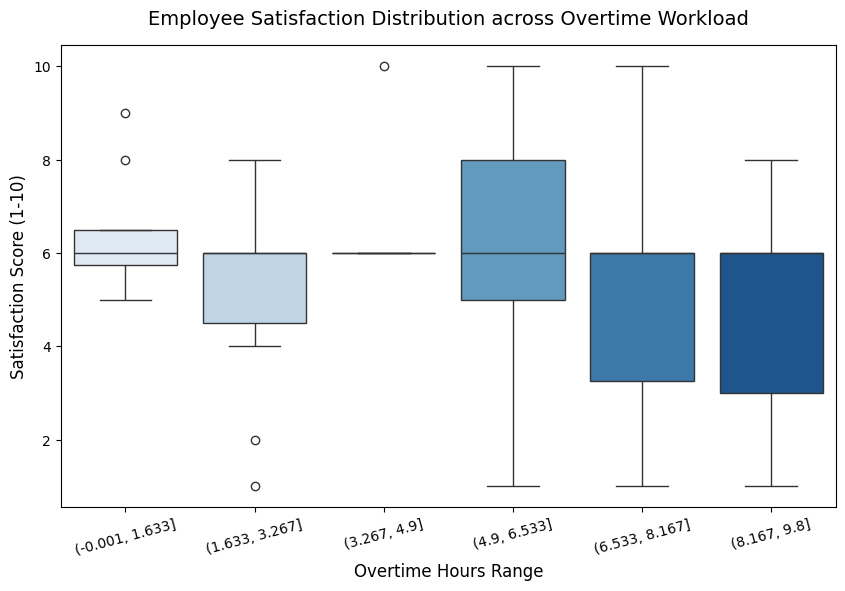

In [84]:
# 2. Initialize a figure size that gives the bins breathing room
plt.figure(figsize=(10, 6))

# 3. Create the box plot
# (Make sure to sort the data by the bins so the x-axis goes from lowest to highest)
sns.boxplot(
data = df.sort_values('overtime_bins'), 
x = 'overtime_bins', 
y = 'satisfaction_score',
palette = 'Blues'  # Generates a nice gradient across the bins
)

# 4. Polish the labels and presentation
plt.title('Employee Satisfaction Distribution across Overtime Workload', fontsize=14, pad=15)
plt.xlabel('Overtime Hours Range', fontsize=12)
plt.ylabel('Satisfaction Score (1-10)', fontsize=12)

# Rotate labels slightly if your string boundaries are long
plt.xticks(rotation=15)

# 5. Render the chart
plt.show()

In [ ]:
interpretation_check = df.groupby('overtime_bins')['satisfaction_score'].describe(percentiles=[0.25, 0.5, 0.75])
print(interpretation_check[['25%', '50%', '75%']])

                  25%  50%  75%
overtime_bins                  
(-0.001, 1.633]  5.75  6.0  6.5
(1.633, 3.267]   4.50  6.0  6.0
(3.267, 4.9]     6.00  6.0  6.0
(4.9, 6.533]     5.00  6.0  8.0
(6.533, 8.167]   3.25  6.0  6.0
(8.167, 9.8]     3.00  6.0  6.0


Calculate average satisfaction scores by educational background.

In [88]:
satisfaction_scores_by_educational_background = df.groupby(['educational_background'])['satisfaction_score'].agg('mean').round(2)
print(satisfaction_scores_by_educational_background)

educational_background
Architecture               6.50
Biology                    6.50
Business Administration    5.67
Chemistry                  7.33
Computer Science           6.50
Economics                  4.86
Engineering                5.14
Law                        5.33
Linguistics                5.86
Mathematics                6.57
Medicine                   6.22
Philosophy                 6.60
Physics                    6.14
Political Science          5.33
Psychology                 4.89
Statistics                 3.38
Name: satisfaction_score, dtype: float64


Visualize the average satisfaction scores by educational background.

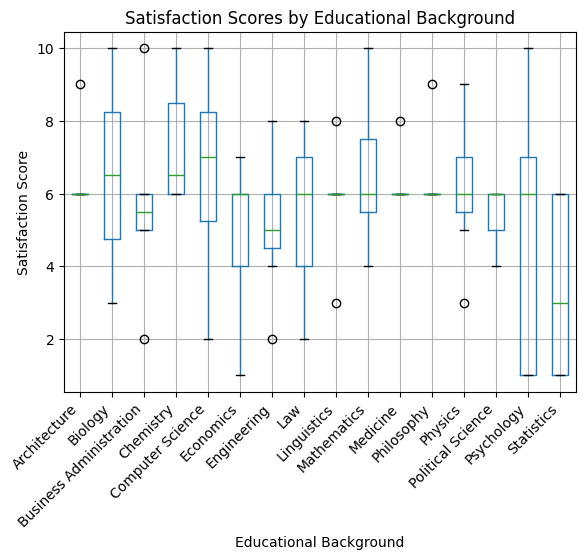

In [89]:
df.boxplot(column='satisfaction_score',by='educational_background')
# Remove the duplicate title added by boxplot
plt.suptitle('')
# Rotate the x-axis labels
plt.xticks(rotation=45, ha='right')
plt.xlabel('Educational Background')  # Add x-axis label
plt.ylabel('Satisfaction Score')  # Add y-axis label
plt.title('Satisfaction Scores by Educational Background')
plt.show()